<a href="https://colab.research.google.com/github/Israel-San-Agustin/Investigacion-de-operacines-/blob/main/Networkx_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<font color = "coral"> **Tutorial networkx 1**

En este cuaderno se describe la solucion tres problemas de redes
**arbol de expancion minima, ruta mas corta, flujo maximo**

Usando la documentacion de la biblioteca <font color = "blue">
[Networkx](https://networkx.org/en/)

https://networkx.org/en/

In [80]:
import networkx as nx
import matplotlib.pyplot as plt

# <font color = "lightcoral">***Red principal***

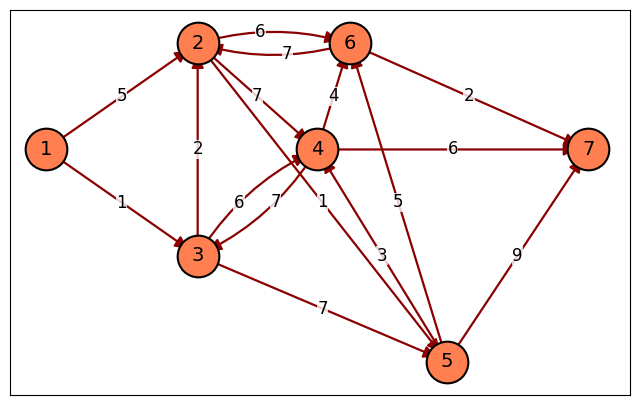

In [81]:
#  Crear el grafo dirigido
G = nx.DiGraph()
G.add_nodes_from([1,2,3,4,5,6,7])

#  Grafica dirigida
G.add_edges_from([
    (1, 2, {"weight": 5}),
    (1, 3, {"weight": 1}),

    (3, 2, {"weight": 2}),

    (2, 4, {"weight": 7}),
    (4, 3, {"weight": 7}),
    (3, 4, {"weight": 6}),

    (2, 5, {"weight": 1}),

    (2, 6, {"weight": 6}),
    (6, 2, {"weight": 7}),

    (3, 5, {"weight": 7}),

    (4, 6, {"weight": 4}),
    (5, 4, {"weight": 3}),

    (4, 7, {"weight": 6}),

    (5, 6, {"weight": 5}),
    (5, 7, {"weight": 9}),

    (6, 7, {"weight": 2}),
])

# posicion o distancia de los nodos
pos = {
    1: (0, 1),
    2: (1.4, 2),
    3: (1.4, 0),
    4: (2.5, 1),
    5: (3.7, -1),
    6: (2.8, 2),
    7: (5.0, 1),
}

plt.figure(figsize=(8, 5))

# 4. Dibujar los nodos (círculos con el número adentro)
nx.draw_networkx_nodes(
    G, pos, node_color="coral", edgecolors="black", node_size=900, linewidths=1.5
)

nx.draw_networkx_labels(G, pos, font_size=14, font_weight="normal")

# 5. Dibujar las aristas y sus distancias uno por uno

for u, v, data in G.edges(data=True):
    # Si la conexión es de ida y vuelta, curvamos la flecha para que no se encimen
    if G.has_edge(v, u):

        if u == v:
         rad = 0.18
         posicion_etiqueta = (
            0.2  # Desplaza ligeramente el texto para que siga la curva
          )
        else:
            rad = -0.15
            posicion_etiqueta = 0.4
    else:
        rad = 0.0
        posicion_etiqueta = 0.5  # Justo en el medio si la línea es recta

     # Dibujar la flecha
    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle="-|>",
        arrowsize=18,
        width=1.6,
        edge_color="#8B0000",
    )

    # dibuja la distancia de esta arista específica

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels={(u, v): data["weight"]},
        label_pos=posicion_etiqueta,
        font_size=12,
        font_color="black",
        rotate=False,  # Mantiene los números siempre legibles en horizontal
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.8,
            pad=0.2
        ),
        connectionstyle=f"arc3,rad={rad}"
    )


plt.show()

#<font color = "darksalmon">***Arbol de expancion***

### <font color="lightpink">**Algoritmo de árbol de expansión mínima**</font>

Sea N = {1, 2,...,n} el conjunto de nodos de la red

Definimos:

<font color="skyblue">$C_k$ </font> = {Conjunto de nodos conectados de forma permanete en la iteracion k}

<font color="skyblue">$\overline{C_k}$ </font> = {Conjunto de nodos que todavia se deben conectar de forma permanente}
<br>

<font color="steelblue">Paso 0:  </font> $C_0 = \emptyset$ ; $\overline{C_0} = N$

<font color="steelblue">Paso 1:  </font> Comenzar con cualquier nodo en $\overline{C_0}$ y hacer $C_γ = {\gamma}$

$\overline{C_1} = N - \{ i \}$ Hacer k = 2

<font color="darkslategray">Paso general $k$:  </font> seleccionar un nodo $j^*$ en el conjunto no conectado <font color="skyblue">$\overline{C}_{k - 1}$ </font> que produzca el <font color="skyblue">*arco mas corto* </font> de un nodo conectado en el con junto <font color="skyblue">$C_{k-1}$ </font>

Enlazar a $j^*$ en forma permanente con <font color="skyblue">$C_{k-1}$ </font> es decir:

<font color="skyblue">$C_k = C_{k-1} + \{j^*\}$ </font>, <font color="skyblue">$\overline{C}_k = \overline{C}_{k - 1} - \{j^*\}$ </font>

Si $\overline{C}_k = \emptyset$ Detener

Otro caso: hacer $k = k + 1$ y repetir el paso $k$

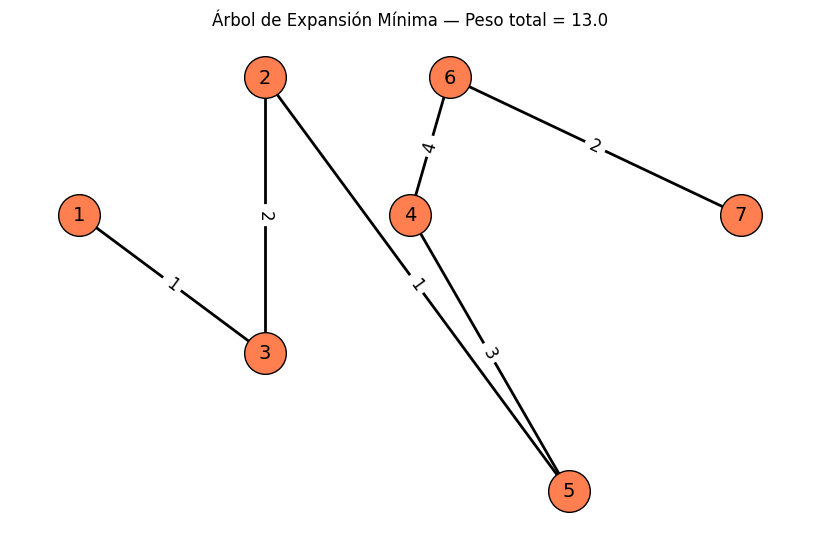

Entonces la ruta minima es :
1 → 3 → 2 → 5 → 4 → 6 → 7 = 13


In [82]:
# Árbol de expansión mínima
AEM = nx.minimum_spanning_tree(G.to_undirected(), weight="weight")

#figura
plt.figure(figsize=(8, 5))

nx.draw(
    AEM,
    pos,
    with_labels=True,
    node_color="coral",
    edgecolors="black",
    node_size=900,
    width=2,
    font_size=14
)

# Mostrar las distancias
labels = nx.get_edge_attributes(AEM, "weight")
nx.draw_networkx_edge_labels(
    AEM,
    pos,
    edge_labels=labels,
    font_size=12
)

plt.title(
    f"Árbol de Expansión Mínima — Peso total = {AEM.size(weight='weight')}"
)

plt.axis("off")
plt.show()

# Obtener la ruta desde 1 hasta 7
ruta = nx.shortest_path(AEM, source=1, target=7)

# Imprimir la ruta y su resultado
print("Entonces la ruta minima es :")
print(" → ".join(map(str, ruta)), "= " + str(nx.shortest_path_length(AEM, source=1, target=7, weight="weight")))

#<font color = "lightcoral"> ***La ruta mas corta***

###<font color = "hotpink">**Algoritmo de la ruta mas corta**</font>

<font color = "tomato"> Objetivo de lan-esima iteración </font> encontrar eln-esimo nodo mas cercano al
origen Repetir para $n=1,2,3,...$ hasta que el $n-esimo$ nodo mas cercano sea el destino.

<font color = "tomato"> Datos de la $n-ésima$ iteración: </font> $n - 1$ nodos mas cercanos al origen - encontrados en itraciones previas, inclida su ruta mas corta y la distancia desde el origen $($estos son <font color = "tomato">nodos resueltos </font> el resto son <font color = "tomato">nodos no resueltos</font>$) $

<font color = "tomato"> candidato a $n-ésimo$ nodo mas cercano: </font> cada nodo no resuelto con conexion directa a uno o mas nodos resueltos tomar el nodo tomar el nodo no resuelto que tiene la ligadura mas corta $($los empates proporciona candidatos adidatos adicionales$)$

In [83]:
import pandas as pd #libreria que ayuda a dar forma a la tabla

# Nodo inicial
inicio = 1

# Conjunto de nodos resueltos
resueltos = {inicio}

# Distancias acumuladas
distancias = {inicio: 0}

# Última conexión
conexiones = {inicio: "-"}

# Tabla
tabla = []

n = 1

while len(resueltos) < len(G.nodes):

    candidatos = []

    # Buscar conexiones desde nodos resueltos hacia nodos no resueltos
    for u in resueltos:
        for v in G.successors(u):

            if v not in resueltos:

                distancia = distancias[u] + G[u][v]["weight"]

                candidatos.append((v, distancia, u))

    # Elegir el nodo no resuelto más cercano
    if not candidatos:
        break

    nodo, distancia_minima, anterior = min(
        candidatos,
        key=lambda x: x[1]
    )

    # Información de los candidatos
    conexiones_directas = ", ".join(
        f"{u}→{v}"
        for v, d, u in candidatos
    )

    # Guardar fila
    tabla.append({
        "n": n,
        "Nrcdannr": conexiones_directas, #Nodos resueltos conectados directamente a nodos no resueltos
        "Nnrmc": nodo, #Nodo no resuelto más cercano
        "Dt": distancia_minima, #Distancia total involucrada
        "n-ésimo": nodo, #n-ésimo nodo más cercano
        "Dm": distancia_minima, #Distancia mínima
        "Última conexión": f"{anterior}→{nodo}"
    })

    # Agrega los nodos a resueltos
    resueltos.add(nodo)
    distancias[nodo] = distancia_minima
    conexiones[nodo] = f"{anterior}→{nodo}"

    n += 1


# Mustra la tabla
df = pd.DataFrame(tabla)

print(df.to_string(index=False))


# resueltado de la ruta final
ruta = nx.shortest_path(
    G,
    source=1,
    target=7,
    weight="weight"
)

#Muestra el resuntaldo de la distanciq minima
distancia_final = nx.shortest_path_length(
    G,
    source=1,
    target=7,
    weight="weight"
)
#imprime los nodos mas corta
print("\nRuta más corta:")
print(" → ".join(map(str, ruta)))

#imprime la distancia minima
print("Distancia total:", distancia_final)

 n                     Nrcdannr  Nnrmc  Dt  n-ésimo  Dm Última conexión
 1                     1→2, 1→3      3   1        3   1             1→3
 2           1→2, 3→2, 3→4, 3→5      2   3        2   3             3→2
 3      2→4, 2→5, 2→6, 3→4, 3→5      5   4        5   4             2→5
 4 2→4, 2→6, 3→4, 5→4, 5→6, 5→7      4   7        4   7             3→4
 5      2→6, 4→6, 4→7, 5→6, 5→7      6   9        6   9             2→6
 6                4→7, 5→7, 6→7      7  11        7  11             6→7

Ruta más corta:
1 → 3 → 2 → 6 → 7
Distancia total: 11


#<font color = "violet"> ***Problema 2***

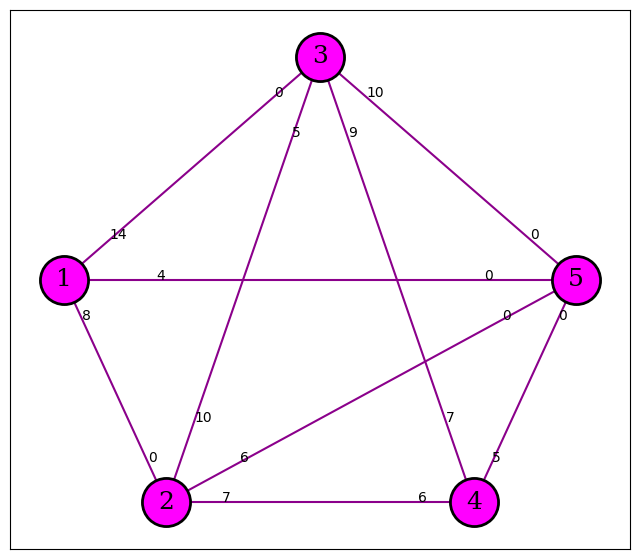

In [92]:
#Crear el grafo no dirigido
G = nx.Graph()

# Definir los nodos
nodes = [1, 2, 3, 4, 5]
G.add_nodes_from(nodes)

# Definir las conexiones y sus dos valores
edges = [
    (1, 3, {"inicio": 14, "final": 0}),
    (1, 5, {"inicio": 4,  "final": 0}),
    (1, 2, {"inicio": 8,  "final": 0}),

    (3, 2, {"inicio": 10, "final": 5}),
    (3, 4, {"inicio": 9,  "final": 7}),
    (3, 5, {"inicio": 10, "final": 0}),

    (2, 4, {"inicio": 7, "final": 6}),
    (2, 5, {"inicio": 6, "final": 0}),

    (4, 5, {"inicio": 5, "final": 0}),
]

G.add_edges_from(edges)

# Posiciones de los nodos
pos = {
    1: (-1.0, 0.1),
    2: (-0.6, -0.8),
    3: (0.0, 1.0),
    4: (0.6, -0.8),
    5: (1.0, 0.1),
}

# Dibujar las líneas
fig, ax = plt.subplots(figsize=(8, 7))

nx.draw_networkx_edges(
    G,
    pos,
    ax=ax,
    width=1.5,
    edge_color="darkmagenta"
)

# Dibujar nodos
nx.draw_networkx_nodes(
    G,
    pos,
    ax=ax,
    node_size=1200,
    node_color="magenta",
    edgecolors="black",
    linewidths=2
)

# Números de los nodos
nx.draw_networkx_labels(
    G,
    pos,
    ax=ax,
    font_size=18,
    font_family="serif"
)

# Dibujar los dos valores de cada conexión
for u, v, datos in G.edges(data=True):

    x1, y1 = pos[u]
    x2, y2 = pos[v]

    #indica el número cerca del nodo inicial
    lx1 = x1 + 0.18 * (x2 - x1)
    ly1 = y1 + 0.18 * (y2 - y1)

    ax.text(
        lx1,
        ly1,
        str(datos["inicio"])
    )

    #indica número cerca del nodo final
    lx2 = x2 + 0.18 * (x1 - x2)
    ly2 = y2 + 0.18 * (y1 - y2)

    ax.text(
        lx2,
        ly2,
        str(datos["final"])
    )
plt.show()

#<font color = "plum"> ***Flujo maximo***

### <font color = "orchid">**Algoritmo de flujo maximo**</font>

Identificar una trayectorio de aumento (si no existe una, los flujos netos
asignados constituyen un patron de flujo optimo).

Identificar la capacidad residual $c^*$ de esta trayectoria si aumenta en $c^*$ el flujo de esta trayectoria

se diominuye en $c^*$ la copacidad residual de cado arco en esta trayectoria
de aumento. se aumenta en $c^* $ la capacidad residual de cada arco en la
dirección opuesta en esta trayectora

Flujo máximo: 25


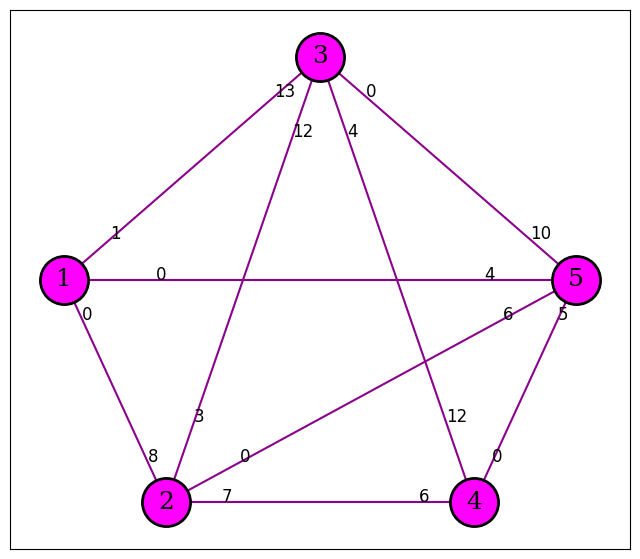

In [91]:
# Crear la red dirigida
G_flujo = nx.DiGraph()

for u, v, datos in edges:

    # Capacidad de u hacia v
    G_flujo.add_edge(
        u, v,
        capacity=datos["inicio"]
    )

    # Capacidad de v hacia u
    G_flujo.add_edge(
        v, u,
        capacity=datos["final"]
    )


# Calcular el flujo máximo
valor_flujo, flow_dict = nx.maximum_flow(
    G_flujo,
    1,
    5
)

print("Flujo máximo:", valor_flujo)

# CONSTRUIR RED
G_res = nx.Graph()

for u, v, datos in edges:

    cap_uv = datos["inicio"]
    cap_vu = datos["final"]

    flujo_uv = flow_dict[u][v]
    flujo_vu = flow_dict[v][u]

    # Capacidad residual
    res_uv = cap_uv - flujo_uv + flujo_vu
    res_vu = cap_vu - flujo_vu + flujo_uv

    G_res.add_edge(
        u,
        v,
        inicio=res_uv,
        final=res_vu
    )

# DIBUJAR RED RESIDUAL

fig, ax = plt.subplots(figsize=(8, 7))

nx.draw_networkx_edges(
    G_res,
    pos,
    ax=ax,
    width=1.5,
    edge_color="darkmagenta"
)

nx.draw_networkx_nodes(
    G_res,
    pos,
    ax=ax,
    node_size=1200,
    node_color="magenta",
    edgecolors="black",
    linewidths=2
)

nx.draw_networkx_labels(
    G_res,
    pos,
    ax=ax,
    font_size=18,
    font_family="serif"
)


# Dibujar valores residuales
for u, v, datos_originales in edges:

    x1, y1 = pos[u]
    x2, y2 = pos[v]

    datos = G_res[u][v]

    # Valor del primer sentido
    lx1 = x1 + 0.18 * (x2 - x1)
    ly1 = y1 + 0.18 * (y2 - y1)

    ax.text(
        lx1,
        ly1,
        str(datos["inicio"]),
        fontsize=12
    )

    # Valor del segundo sentido
    lx2 = x2 + 0.18 * (x1 - x2)
    ly2 = y2 + 0.18 * (y1 - y2)

    ax.text(
        lx2,
        ly2,
        str(datos["final"]),
        fontsize=12
    )

plt.show()